In [1]:
# Part 1: Data Understanding & Preprocessing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
# Load the Wholesale Customers dataset

df = pd.read_csv(r"C:\Users\sudar\Documents\Collage\Placement prep\Machine learing and computer vison\Home Assignment\Home Assignment 3\Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
# Display number of observations and features

print("Number of observations:", df.shape[0])
print("Number of features:", df.shape[1])

Number of observations: 440
Number of features: 8


In [4]:
# Display data types of all columns

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
# Check for missing values

df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [6]:
# Display basic statistical summary

df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [7]:
# Categorical features

categorical_features = [
    "Channel",
    "Region"
]

# Numerical spending features

spending_features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

In [8]:
# Select the six spending attributes for unsupervised learning

X = df[spending_features]

X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [9]:
# Compare variation among spending features

X.std().sort_values(ascending=False)

Fresh               12647.328865
Grocery              9503.162829
Milk                 7380.377175
Frozen               4854.673333
Detergents_Paper     4767.854448
Delicassen           2820.105937
dtype: float64

In [10]:
# Compare minimum and maximum values

X.agg(["min", "max"])

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
min,3,55,3,25,3,3
max,112151,73498,92780,60869,40827,47943


In [11]:
# Standardize the six spending features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
# Convert standardized data back to a DataFrame

X_scaled = pd.DataFrame(
    X_scaled,
    columns=spending_features
)

X_scaled.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


In [13]:
X_scaled.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,4.400000e+02,440.000000,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02
mean,-3.431598e-17,0.000000,-4.037175e-17,3.633457e-17,2.422305e-17,-8.074349e-18
std,1.001138e+00,1.001138,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00
min,-9.496831e-01,-0.778795,-8.373344e-01,-6.283430e-01,-6.044165e-01,-5.402644e-01
25%,-7.023339e-01,-0.578306,-6.108364e-01,-4.804306e-01,-5.511349e-01,-3.964005e-01
50%,-2.767602e-01,-0.294258,-3.366684e-01,-3.188045e-01,-4.336004e-01,-1.985766e-01
75%,3.905226e-01,0.189092,2.849105e-01,9.946441e-02,2.184822e-01,1.048598e-01
max,7.927738e+00,9.183650,8.936528e+00,1.191900e+01,7.967672e+00,1.647845e+01


In [14]:
print("Means after standardization:")
print(X_scaled.mean())

print("\nStandard deviations after standardization:")
print(X_scaled.std())

Means after standardization:
Fresh              -3.431598e-17
Milk                0.000000e+00
Grocery            -4.037175e-17
Frozen              3.633457e-17
Detergents_Paper    2.422305e-17
Delicassen         -8.074349e-18
dtype: float64

Standard deviations after standardization:
Fresh               1.001138
Milk                1.001138
Grocery             1.001138
Frozen              1.001138
Detergents_Paper    1.001138
Delicassen          1.001138
dtype: float64


In [15]:
scaler.fit_transform(X)

array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       ...,
       [ 0.20032554,  1.31467078,  2.34838631, -0.54337975,  2.51121768,
         0.12145607],
       [-0.13538389, -0.51753572, -0.60251388, -0.41944059, -0.56977032,
         0.21304614],
       [-0.72930698, -0.5559243 , -0.57322717, -0.62009417, -0.50488752,
        -0.52286938]], shape=(440, 6))

In [16]:
# Correlation matrix

correlation_matrix = X.corr()

correlation_matrix

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690
Milk,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368
Grocery,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497
Frozen,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947
Detergents_Paper,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291
Delicassen,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000


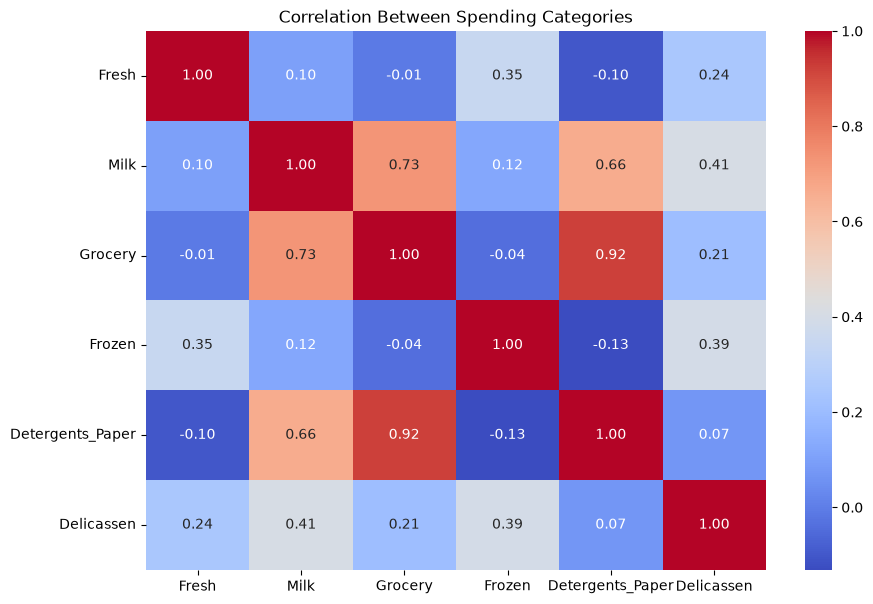

In [17]:
# Visualize correlations

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Spending Categories")
plt.show()

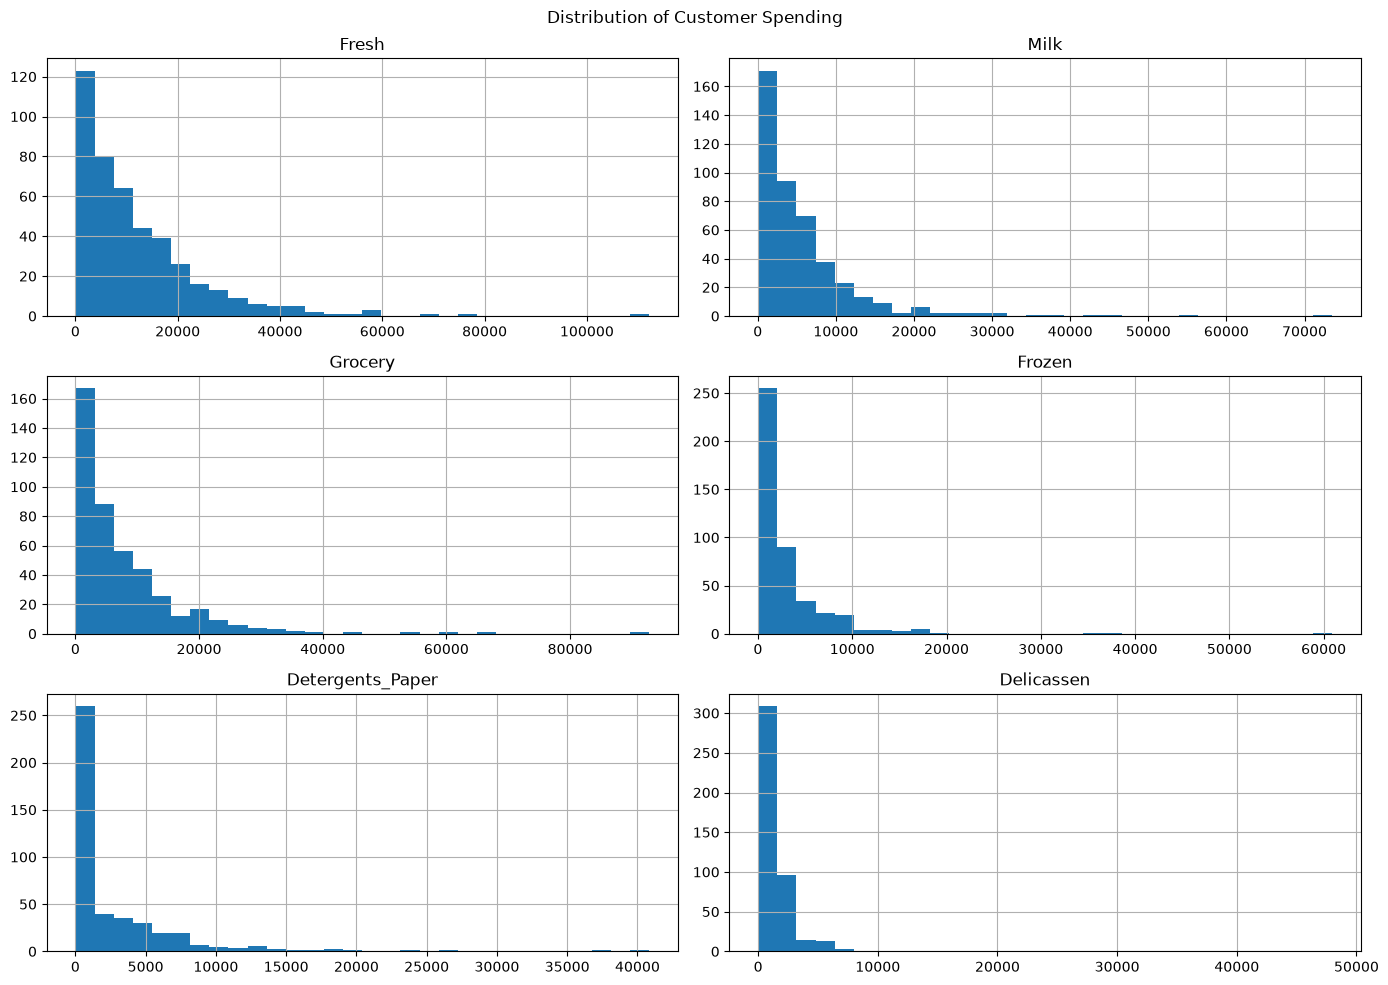

In [18]:
# Visualize distributions of spending features

X.hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Customer Spending")
plt.tight_layout()
plt.show()

### Q1. Variation in spending attributes
Fresh has the largest variation, followed by Grocery and Milk, based on their standard deviations. Delicassen has the lowest variation among the six spending categories.

### Q2. Are all six features on a comparable scale?
No
The ranges are clearly very different.

For example:
Fresh → 3 to 112151
Delicassen → 3 to 47943

If we used these raw values directly for a distance-based algorithm such as K-Means, large-scale features could have a disproportionate influence.

That's why we standardized the data.

### Q3. What could happen if clustering is performed without standardization?
Features with larger numerical scales and variation could dominate the distance calculations, causing the clustering algorithm to give them more influence than smaller-scale features.

### Q4. Which product categories appear to be correlated?
Customers who spend more on Grocery tend to also spend more on Detergents_Paper.
Correlation = 0.92

Milk ↔ Grocery has strong positive correlation. of 0.73...
Milk ↔ Detergents_Paper has 0.66


Other relationships are weaker. For example:
Fresh ↔ Grocery = -0.01...
Fresh ↔ Milk    = 0.10...
Fresh ↔ Detergents_Paper = -0.10



Grocery ↔ Detergents_Paper = 0.92

suggests that these two variables contain highly related information.

This will become interesting in PCA, because PCA is designed to find combinations of variables that explain the major patterns/variance in the data.

### Q5. Are there any unusually high-spending customers?
Yes 
descriptive statistics already give us strong evidence.
For example:

Fresh
Mean = 12,000
Maximum = 112,151

That's a very large difference.

Similarly:

Milk
Mean = 5,796
Maximum = 73,498

Grocery
Mean = 7,951
Maximum = 92,780

Frozen
Mean = 3,072
Maximum = 60,869

So there are customers with unusually high spending.

And your standardized values confirm this.

For example, the maximum standardized values include:

Fresh              7.93
Milk               9.18
Grocery            8.94
Frozen            11.92
Detergents_Paper    7.97
Delicassen         16.48

A standardized value far above zero indicates that the customer is spending substantially above the average for that feature.

In [19]:
# Summary of spending features

summary = pd.DataFrame({
    "Mean": X.mean(),
    "Std": X.std(),
    "Minimum": X.min(),
    "Maximum": X.max()
})

summary.sort_values("Std", ascending=False)

,Mean,Std,Minimum,Maximum
Fresh,12000.297727,12647.328865,3,112151
Grocery,7951.277273,9503.162829,3,92780
Milk,5796.265909,7380.377175,55,73498
Frozen,3071.931818,4854.673333,25,60869
Detergents_Paper,2881.493182,4767.854448,3,40827
Delicassen,1524.870455,2820.105937,3,47943


### Part 2 — PCA

In [20]:
# PCA
from sklearn.decomposition import PCA

In [21]:
# Apply PCA to the standardized data

pca = PCA(n_components=6)

X_pca = pca.fit_transform(X_scaled)

print("Shape of PCA-transformed data:", X_pca.shape)

Shape of PCA-transformed data: (440, 6)


In [25]:
# Create a DataFrame containing all principal components

pca_columns = [
    "PC1",
    "PC2",
    "PC3",
    "PC4",
    "PC5",
    "PC6"
]

X_pca_df = pd.DataFrame(
    X_pca,
    columns=pca_columns
)

X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,0.193291,-0.305100,0.140878,-0.486432,0.495281,-0.007414
1,0.434420,-0.328413,-0.319007,-0.178830,0.365579,0.054572
2,0.811143,0.815096,-1.523416,-1.254082,-0.379054,-0.277539
3,-0.778648,0.652754,-0.163012,0.380060,-0.276138,0.060718
4,0.166287,1.271434,-0.066279,-0.826227,-0.394211,-0.026825


In [26]:
# Explained variance ratio of each principal component

explained_variance = pca.explained_variance_ratio_

for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.4f} ({variance * 100:.2f}%)")

PC1: 0.4408 (44.08%)
PC2: 0.2838 (28.38%)
PC3: 0.1233 (12.33%)
PC4: 0.0940 (9.40%)
PC5: 0.0476 (4.76%)
PC6: 0.0105 (1.05%)


In [27]:
# Variance explained by PC1

pc1_variance = pca.explained_variance_ratio_[0]

print(f"PC1 explains {pc1_variance * 100:.2f}% of the variance.")

PC1 explains 44.08% of the variance.


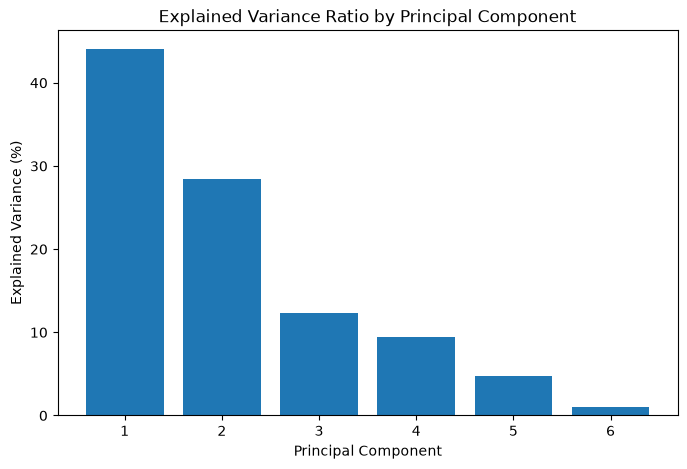

In [28]:
# Plot explained variance ratio

components = range(1, len(explained_variance) + 1)

plt.figure(figsize=(8, 5))

plt.bar(
    components,
    explained_variance * 100
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance Ratio by Principal Component")

plt.xticks(components)
plt.show()

In [29]:
# Calculate cumulative explained variance

cumulative_variance = np.cumsum(explained_variance)

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"First {i} component(s): {variance * 100:.2f}%")

First 1 component(s): 44.08%
First 2 component(s): 72.46%
First 3 component(s): 84.79%
First 4 component(s): 94.19%
First 5 component(s): 98.95%
First 6 component(s): 100.00%


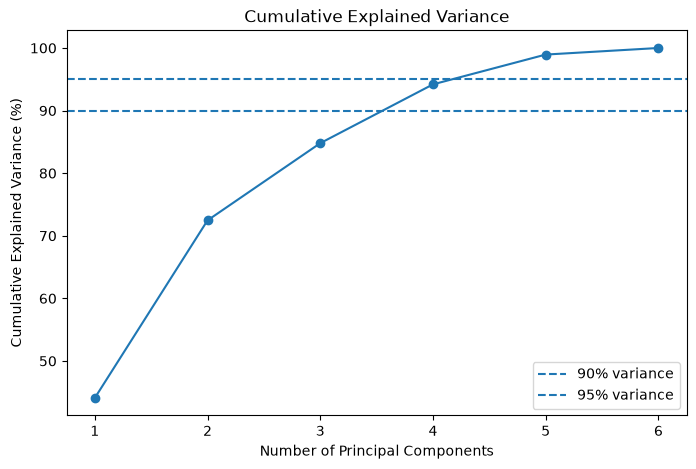

In [30]:
# Plot cumulative explained variance

plt.figure(figsize=(8, 5))

plt.plot(
    components,
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(
    y=90,
    linestyle="--",
    label="90% variance"
)

plt.axhline(
    y=95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")
plt.xticks(components)
plt.legend()

plt.show()

In [31]:
# Number of components required to retain 90% and 95% variance

components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components required for 90% variance:", components_90)
print("Components required for 95% variance:", components_95)

Components required for 90% variance: 4
Components required for 95% variance: 5


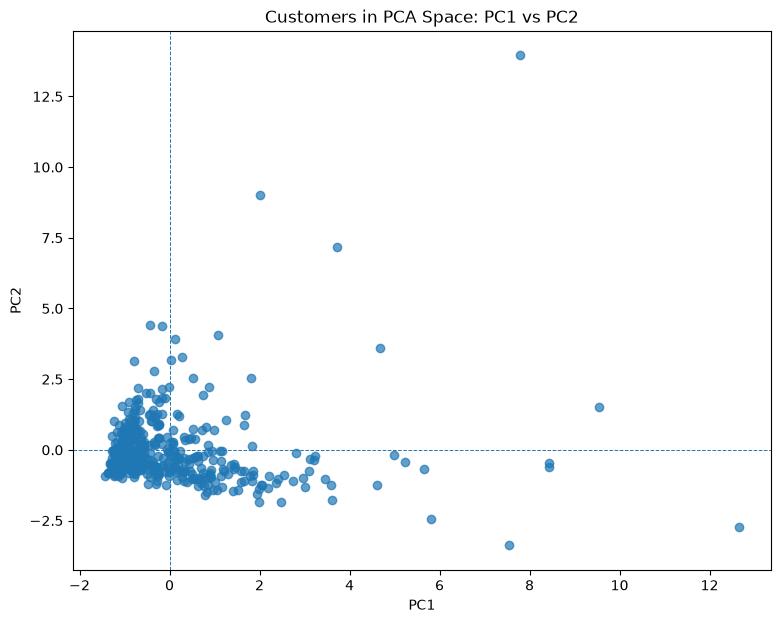

In [32]:
# 2D visualization using PC1 and PC2

plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers in PCA Space: PC1 vs PC2")

plt.axhline(0, linestyle="--", linewidth=0.7)
plt.axvline(0, linestyle="--", linewidth=0.7)

plt.show()

In [33]:
# PCA loadings

loadings = pd.DataFrame(
    pca.components_.T,
    columns=pca_columns,
    index=spending_features
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6
Fresh,0.042884,0.527932,0.812257,-0.236686,-0.048683,-0.036025
Milk,0.545118,0.083168,-0.060388,-0.087190,0.826579,-0.038040
Grocery,0.579256,-0.146088,0.108384,0.105987,-0.314999,0.721745
Frozen,0.051189,0.611278,-0.178386,0.768683,-0.027932,-0.015637
Detergents_Paper,0.548640,-0.255233,0.136192,0.171744,-0.339640,-0.685894
Delicassen,0.248682,0.504207,-0.523904,-0.552065,-0.314701,-0.075134


In [34]:
# Features contributing most strongly to PC1

pc1_loadings = loadings["PC1"].sort_values(
    key=abs,
    ascending=False
)

pc1_loadings

Grocery             0.579256
Detergents_Paper    0.548640
Milk                0.545118
Delicassen          0.248682
Frozen              0.051189
Fresh               0.042884
Name: PC1, dtype: float64

In [35]:
# Features contributing most strongly to PC2

pc2_loadings = loadings["PC2"].sort_values(
    key=abs,
    ascending=False
)

pc2_loadings

Frozen              0.611278
Fresh               0.527932
Delicassen          0.504207
Detergents_Paper   -0.255233
Grocery            -0.146088
Milk                0.083168
Name: PC2, dtype: float64

In [36]:
# Variance retained by the first two principal components

two_pc_variance = cumulative_variance[1]

print(
    f"PC1 + PC2 explain {two_pc_variance * 100:.2f}% "
    "of the total variance."
)

PC1 + PC2 explain 72.46% of the total variance.


In [37]:
# Information lost when using only PC1 and PC2

information_lost = 1 - two_pc_variance

print(
    f"Information lost: {information_lost * 100:.2f}%"
)

Information lost: 27.54%


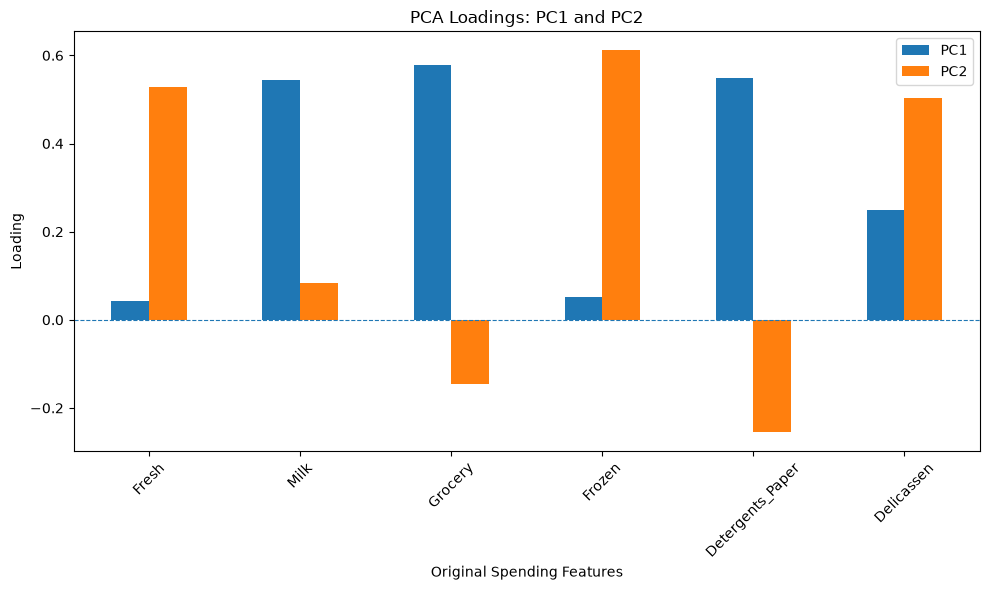

In [38]:
# Visualize PCA loadings for PC1 and PC2

loadings[["PC1", "PC2"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("PCA Loadings: PC1 and PC2")
plt.xlabel("Original Spending Features")
plt.ylabel("Loading")
plt.xticks(rotation=45)

plt.axhline(0, linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

### Q6. How many principal components are required to represent most of the information?

The first **4 principal components** are required to retain approximately **90% of the total variance**, while **5 principal components** are required to retain approximately **95%**. Therefore, the six-dimensional customer spending data can be reduced to 4 or 5 dimensions while preserving most of the information.

### Q7. How much variance is explained by PC1?

The first principal component (PC1) explains approximately **44.08% of the total variance** in the standardized customer spending data. This means PC1 captures the largest single portion of the variation present in the six original spending features.

Q8. Which original features contribute most strongly to PC1?

PC1 loadings are:

Grocery = 0.5793
Detergents_Paper = 0.5486
Milk = 0.5451
Delicassen = 0.2487
Frozen = 0.0512
Fresh = 0.0429

Therefore, Grocery, Detergents_Paper, and Milk contribute most strongly.


### Q8. Which original features contribute most strongly to PC1?

The original features contributing most strongly to PC1 are **Grocery (0.5793)**, **Detergents_Paper (0.5486)**, and **Milk (0.5451)**. Their relatively large positive loadings indicate that PC1 is strongly associated with spending in these three product categories.

Q9. Which features contribute most strongly to PC2?

PC2 loadings are:

Frozen = 0.6113
Fresh = 0.5279
Delicassen = 0.5042
Detergents_Paper = -0.2552
Grocery = -0.1461
Milk = 0.0832

The largest contributions by magnitude are Frozen, Fresh and Delicassen.


The features contributing most strongly to PC2 are **Frozen (0.6113)**, **Fresh (0.5279)**, and **Delicassen (0.5042)**. These features have the largest absolute loadings on PC2, indicating that they have the strongest influence on the second principal component.

### Q10. Can six-dimensional customer behaviour be reasonably represented using only two principal components?

Your result:

PC1 + PC2 = 72.46%

So two dimensions retain a substantial amount of information, but they don't retain everything.


Yes, the six-dimensional customer behaviour can be **reasonably visualized** using the first two principal components because PC1 and PC2 together explain approximately **72.46% of the total variance**. However, 27.54% of the variance is not represented in the 2D projection, so the two-dimensional representation does not preserve all the information in the original data.

### Q11. What information is lost when reducing six dimensions to two?

When the six-dimensional data is reduced to PC1 and PC2, approximately **27.54% of the total variance** is lost. This corresponds to the information represented by **PC3, PC4, PC5, and PC6**. Therefore, the 2D representation captures the major patterns in the data but does not preserve all aspects of customer spending behaviour.

### Important Concept: Why is PCA useful before clustering even though PCA itself does not create clusters?

PCA is useful before clustering because it can reduce the dimensionality of the dataset while retaining most of its variance. It can reduce redundancy, simplify visualization, and make the major patterns in the data easier to identify. However, PCA itself does not assign customers to clusters; algorithms such as K-Means, Hierarchical Clustering, GMM, and DBSCAN perform the actual clustering.

### Part 3 — K-Means Clustering

In [39]:
# K-Means clustering

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [40]:
# Run K-Means for K = 2 to 6

k_values = range(2, 7)

inertias = []
silhouette_scores = []

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(sil_score)

In [41]:
# Store K-Means evaluation results

kmeans_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

kmeans_results

,K,Inertia,Silhouette Score
0,2,1956.124278,0.547215
1,3,1608.431149,0.548287
2,4,1317.838361,0.348471
3,5,1058.771253,0.369040
4,6,915.741260,0.378229


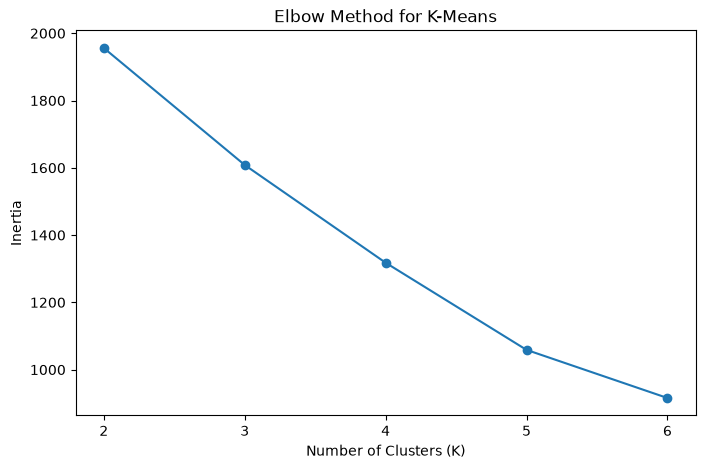

In [42]:
# Elbow curve

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.xticks(list(k_values))
plt.show()

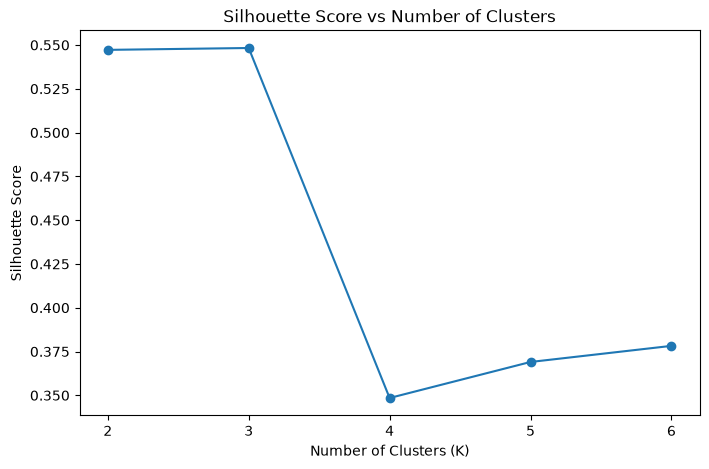

In [43]:
# Silhouette Score vs K

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")

plt.xticks(list(k_values))
plt.show()

In [44]:
# K with the highest silhouette score

best_k_silhouette = list(k_values)[
    np.argmax(silhouette_scores)
]

print("Best K according to Silhouette Score:",
      best_k_silhouette)

print(
    "Highest Silhouette Score:",
    max(silhouette_scores)
)

Best K according to Silhouette Score: 3
Highest Silhouette Score: 0.5482872649700601


In [45]:
# Set the selected number of clusters after examining the evaluation results

selected_k = best_k_silhouette

print("Selected K:", selected_k)

Selected K: 3


In [46]:
# Fit final K-Means model

final_kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_scaled)

In [47]:
# Add cluster labels to the dataset

df_kmeans = df.copy()

df_kmeans["KMeans_Cluster"] = final_labels

df_kmeans.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,KMeans_Cluster
0,2,3,12669,9656,7561,214,2674,1338,1
1,2,3,7057,9810,9568,1762,3293,1776,1
2,2,3,6353,8808,7684,2405,3516,7844,1
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1


In [48]:
# Number of customers in each K-Means cluster

cluster_counts = df_kmeans["KMeans_Cluster"].value_counts().sort_index()

cluster_counts

KMeans_Cluster
0     45
1    393
2      2
Name: count, dtype: int64

In [49]:
# Average spending by K-Means cluster

cluster_profiles = df_kmeans.groupby(
    "KMeans_Cluster"
)[spending_features].mean()

cluster_profiles

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
KMeans_Cluster,,,,,,
0,10440.933333,19386.422222,28656.088889,2190.244444,13327.800000,2374.200000
1,12062.913486,4115.099237,5534.966921,2940.676845,1696.170483,1299.114504
2,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000


In [50]:
# Calculate average overall spending for each cluster

cluster_profiles["Total_Average_Spending"] = (
    cluster_profiles[spending_features].sum(axis=1)
)

cluster_profiles.sort_values(
    "Total_Average_Spending",
    ascending=False
)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Average_Spending
KMeans_Cluster,,,,,,,
2,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000,158280.000000
0,10440.933333,19386.422222,28656.088889,2190.244444,13327.800000,2374.200000,76375.688889
1,12062.913486,4115.099237,5534.966921,2940.676845,1696.170483,1299.114504,27648.941476


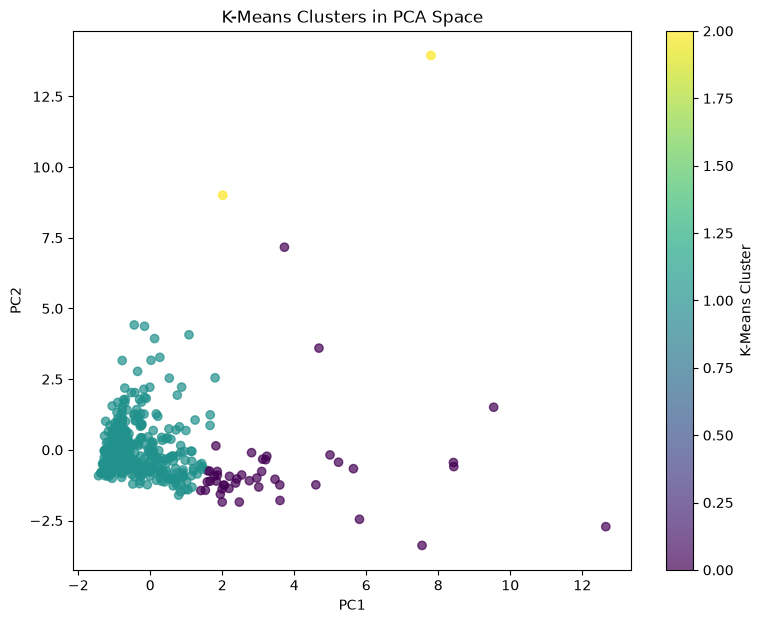

In [51]:
# Visualize K-Means clusters in PCA space

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=final_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in PCA Space")

plt.colorbar(
    scatter,
    label="K-Means Cluster"
)

plt.show()

In [52]:
# Cluster centroids in standardized feature space

centroids = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=spending_features
)

centroids

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,-0.123436,1.843487,2.181209,-0.181823,2.193481,0.301512
1,0.004957,-0.228048,-0.254553,-0.027068,-0.248890,-0.080143
2,1.803356,3.332987,0.942519,9.409801,-0.446409,8.964157


### Q12. At what value of K does the elbow appear?

The Elbow Method suggests an elbow at approximately **K = 4**. The inertia decreases substantially as K increases from 2 to 4, while the improvement becomes less pronounced after this point. Therefore, K = 4 is a reasonable choice based on the Elbow Method, although the elbow is not very sharp.

### Q13. Does the Silhouette Score suggest the same K as the Elbow Method?

No. The two methods suggest different values of K. The Elbow Method suggests approximately **K = 4**, while the Silhouette Score is highest at **K = 3**, with a score of approximately **0.5483**. Therefore, the two evaluation methods do not provide the same recommendation.

### Q14. If the two methods suggest different K values, which one would you prefer and why?

In this experiment, **K = 3** is preferred because it has the highest Silhouette Score (**0.5483**), indicating better cluster separation and cohesion than the other tested values. However, the K = 3 solution should be interpreted carefully because one cluster contains only **2 customers**. These customers appear to have unusually high spending, so the small cluster may represent genuine high-value or outlier customers rather than a large customer segment.

### Q15. Are the K-Means clusters clearly separated in the PCA plot?

The K-Means clusters show **partial separation** in the PCA plot. The two-customer cluster is clearly separated from the main group because these customers have unusually high spending patterns. However, the larger clusters show some overlap in the PC1–PC2 projection. Since the original clustering was performed using all six standardized features and the plot uses only two principal components, the 2D visualization does not represent the complete six-dimensional cluster separation.

### Q16. Which cluster contains customers with the highest overall spending?

**Cluster 2** contains the customers with the highest overall spending. Its average spending is particularly high for Fresh, Milk, Frozen, and Delicassen. However, Cluster 2 contains only **2 customers**, so this segment represents a very small group of unusually high-spending customers rather than a large customer segment.

### Q17. Which product categories distinguish the clusters?

The clusters are distinguished by their different spending profiles. **Cluster 0** has relatively high spending on Milk, Grocery, and Detergents_Paper. **Cluster 1**, which contains the majority of customers, has comparatively moderate spending across most categories. **Cluster 2** is characterized by extremely high spending on Fresh, Milk, Frozen, and Delicassen, although it contains only 2 customers. These differences show how K-Means can identify distinct customer spending patterns.

### Important Concept: Does K-Means always produce the "correct" number of clusters?

No. K-Means does not automatically determine the true or correct number of clusters because the value of K must be specified in advance. Different values of K produce different cluster structures. In this experiment, the Elbow Method suggested approximately K = 4, while the highest Silhouette Score occurred at K = 3. Therefore, selecting the number of clusters requires considering evaluation metrics together with visualization, cluster sizes, interpretability, and domain knowledge.

K=3 is selected based on the highest Silhouette Score (0.5483), although the Elbow Method suggests approximately K=4. The K=3 solution reveals a dominant customer group, a smaller high-spending group, and two extreme high-spending customers. This highlights both the usefulness and limitations of K-Means for this dataset.

### Part 4 — Hierarchical Agglomerative Clustering

In [53]:
# Hierarchical Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

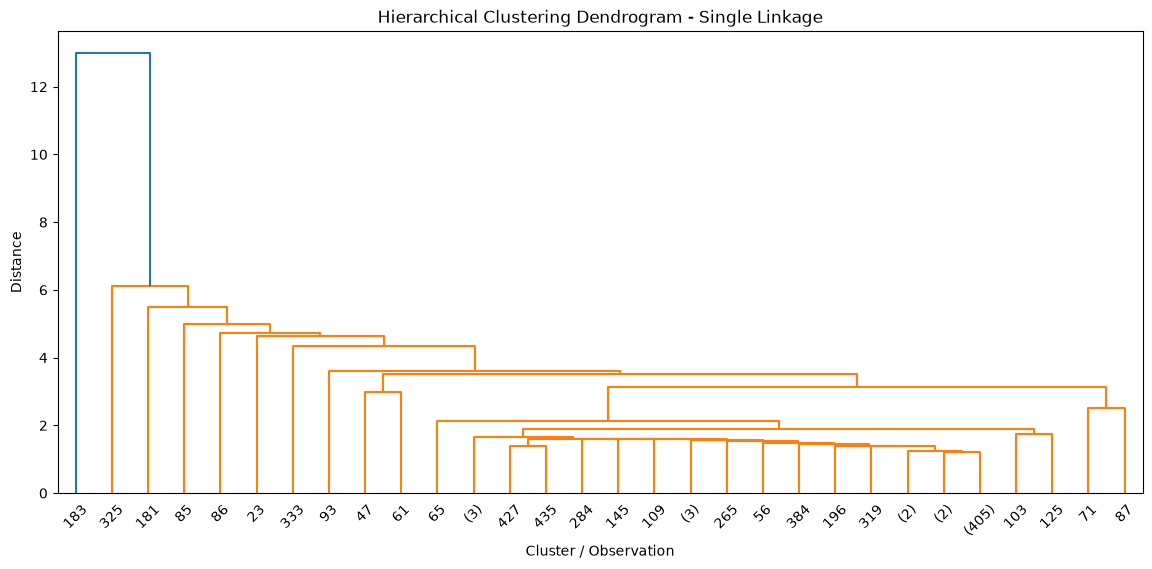

In [54]:
# Single linkage dendrogram

single_linkage = linkage(
    X_scaled,
    method="single"
)

plt.figure(figsize=(14, 6))

dendrogram(
    single_linkage,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram - Single Linkage")
plt.xlabel("Cluster / Observation")
plt.ylabel("Distance")

plt.show()

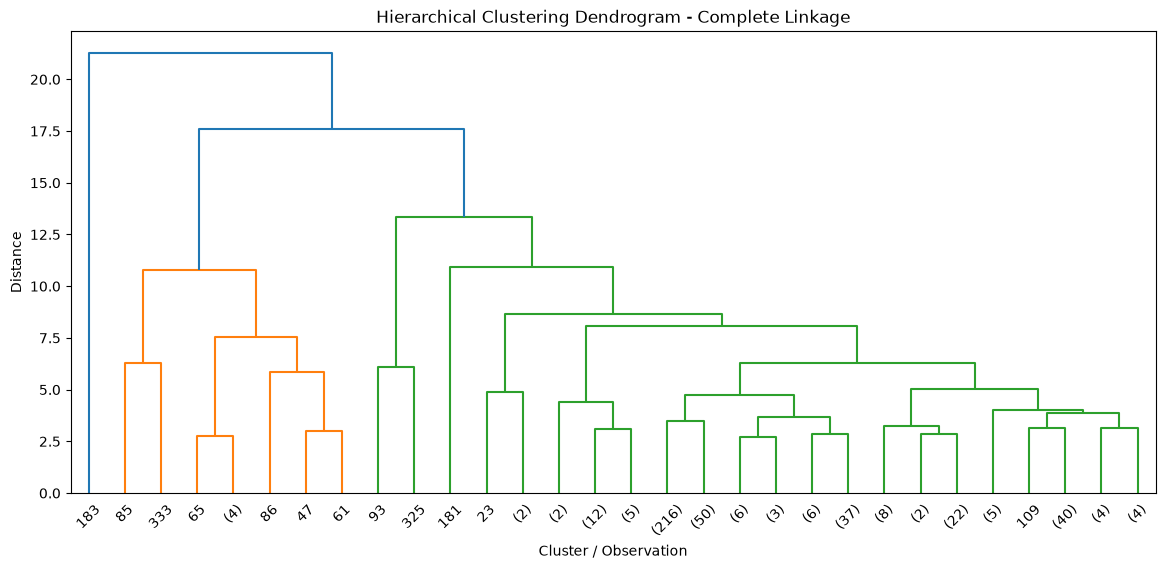

In [55]:
# Complete linkage dendrogram

complete_linkage = linkage(
    X_scaled,
    method="complete"
)

plt.figure(figsize=(14, 6))

dendrogram(
    complete_linkage,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram - Complete Linkage")
plt.xlabel("Cluster / Observation")
plt.ylabel("Distance")

plt.show()

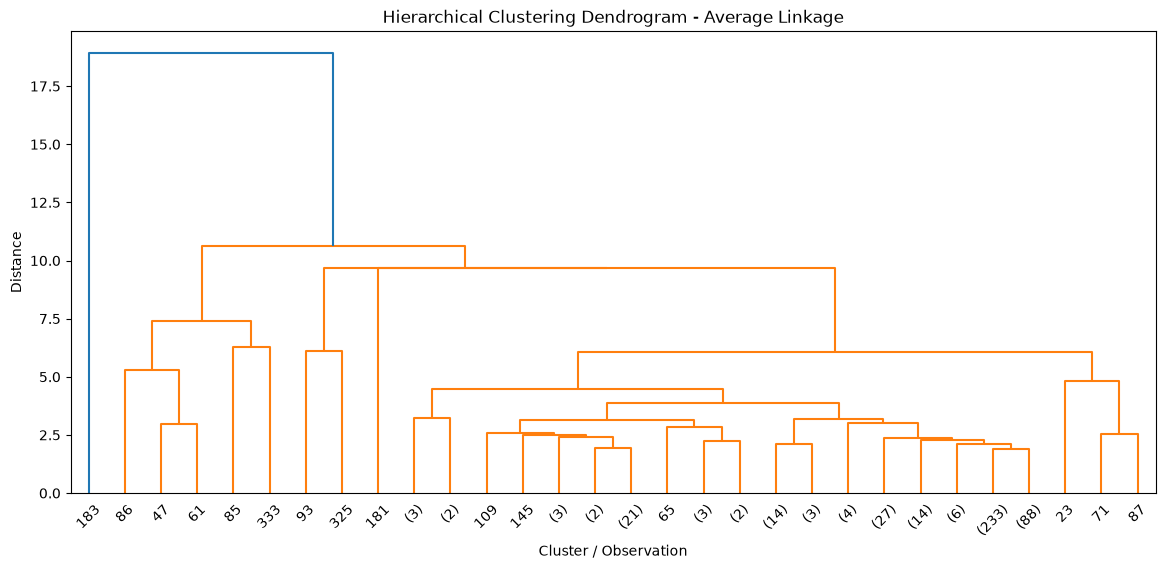

In [56]:
# Average linkage dendrogram

average_linkage = linkage(
    X_scaled,
    method="average"
)

plt.figure(figsize=(14, 6))

dendrogram(
    average_linkage,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram - Average Linkage")
plt.xlabel("Cluster / Observation")
plt.ylabel("Distance")

plt.show()

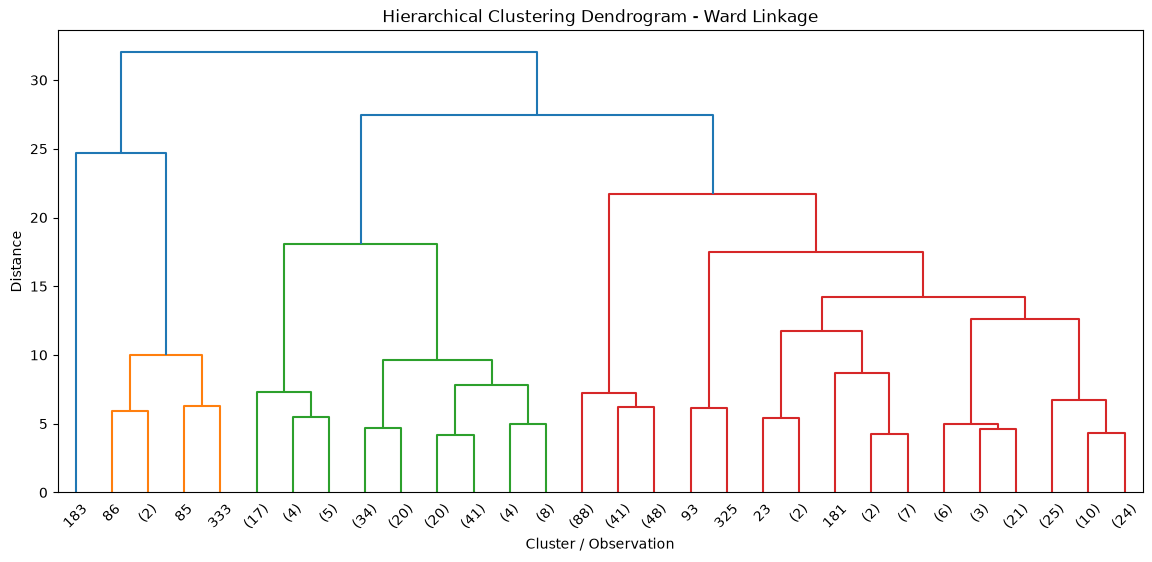

In [57]:
# Ward linkage dendrogram

ward_linkage = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(14, 6))

dendrogram(
    ward_linkage,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram - Ward Linkage")
plt.xlabel("Cluster / Observation")
plt.ylabel("Distance")

plt.show()

In [58]:
# Agglomerative clustering with 3 clusters

selected_hierarchical_k = 3

hierarchical_model = AgglomerativeClustering(
    n_clusters=selected_hierarchical_k,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

In [59]:
# Add hierarchical cluster labels

df_hierarchical = df.copy()

df_hierarchical["Hierarchical_Cluster"] = hierarchical_labels

df_hierarchical.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Hierarchical_Cluster
0,2,3,12669,9656,7561,214,2674,1338,2
1,2,3,7057,9810,9568,1762,3293,1776,2
2,2,3,6353,8808,7684,2405,3516,7844,2
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1


In [60]:
# Number of customers in each hierarchical cluster

hierarchical_counts = (
    df_hierarchical["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

hierarchical_counts

Hierarchical_Cluster
0      6
1    281
2    153
Name: count, dtype: int64

In [61]:
# Average spending by hierarchical cluster

hierarchical_profiles = (
    df_hierarchical
    .groupby("Hierarchical_Cluster")[spending_features]
    .mean()
)

hierarchical_profiles

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Hierarchical_Cluster,,,,,,
0,27477.000000,43542.166667,54588.500000,8285.666667,25018.333333,10247.833333
1,15048.932384,3017.298932,3791.761566,3837.316726,758.007117,1309.900356
2,5794.241830,9419.888889,13761.738562,1461.764706,5913.379085,1577.607843


In [62]:
# Silhouette Score for hierarchical clustering

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    f"Hierarchical Clustering Silhouette Score: "
    f"{hierarchical_silhouette:.4f}"
)

Hierarchical Clustering Silhouette Score: 0.2646


In [63]:
# Compare different linkage methods

linkage_methods = [
    "single",
    "complete",
    "average",
    "ward"
]

hierarchical_results = []

for method in linkage_methods:
    
    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )
    
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    hierarchical_results.append({
        "Linkage": method,
        "Number of Clusters": len(np.unique(labels)),
        "Silhouette Score": score
    })

hierarchical_results = pd.DataFrame(
    hierarchical_results
)

hierarchical_results

,Linkage,Number of Clusters,Silhouette Score
0,single,3,0.796648
1,complete,3,0.711531
2,average,3,0.767580
3,ward,3,0.264609


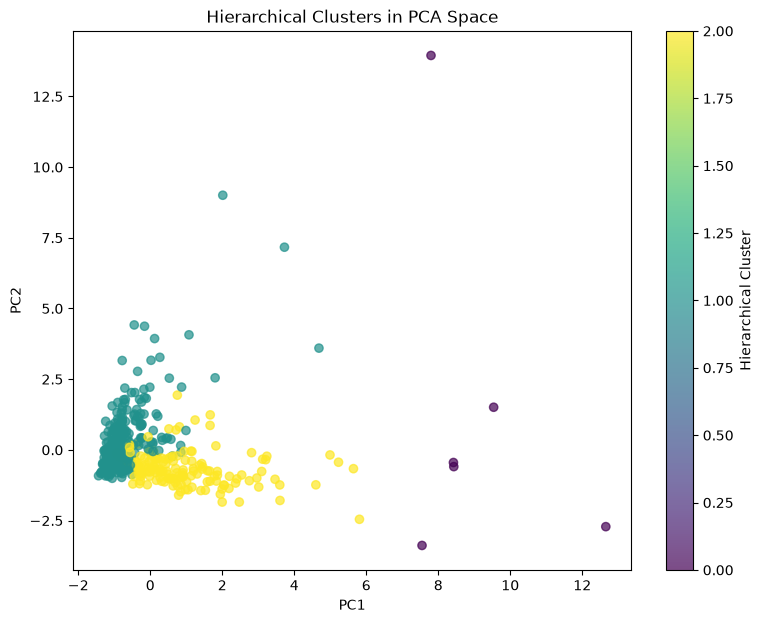

In [64]:
# Visualize hierarchical clusters in PCA space

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=hierarchical_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clusters in PCA Space")

plt.colorbar(
    scatter,
    label="Hierarchical Cluster"
)

plt.show()

In [66]:
# Compare K-Means and hierarchical cluster assignments

comparison = pd.crosstab(
    df_kmeans["KMeans_Cluster"],
    df_hierarchical["Hierarchical_Cluster"]
)

comparison

Hierarchical_Cluster,0,1,2
KMeans_Cluster,,,
0,5,2,38
1,0,278,115
2,1,1,0


### Q18. What does the dendrogram tell you about the similarity between customers?

The dendrogram represents the hierarchical similarity between customers. Customers or groups that are merged at a smaller distance are more similar, while groups merged at a larger distance are more dissimilar. The dendrograms also show that the structure of the customer groups changes depending on the linkage method used.

### Q19. At what level would you cut the dendrogram to obtain meaningful clusters?

The dendrograms indicate that a cut producing approximately **3 clusters** is a reasonable choice. The exact cutting distance depends on the linkage method because each method measures the distance between clusters differently. Therefore, the dendrogram can be cut just before a major increase in merging distance to obtain three relatively distinct customer groups.

### Q20. Does the dendrogram suggest the same number of clusters as K-Means?

Yes. The dendrograms provide a reasonable interpretation of approximately **3 clusters**, which is also the number selected for K-Means based on its Silhouette Score. However, having the same number of clusters does not mean that both algorithms produce the same customer grouping. The clustering structure and quality can still differ significantly between the two methods.

### Q21. How does changing the linkage method affect the clusters?

Changing the linkage method significantly affects the resulting cluster structure because each method defines the distance between clusters differently. In this experiment, the Silhouette Scores were **0.7966 for Single Linkage, 0.7115 for Complete Linkage, 0.7676 for Average Linkage, and 0.2646 for Ward Linkage**. This shows that the choice of linkage method has a substantial effect on cluster quality for this dataset.

### Q22. Which linkage method gives the most meaningful segmentation?

Based on the Silhouette Score, **Single Linkage** gives the highest-quality segmentation, with a score of **0.7966**, followed by Average Linkage (0.7676) and Complete Linkage (0.7115). Ward Linkage performs substantially worse with a score of 0.2646. However, Single Linkage can produce a chaining effect, so Average Linkage may provide a more balanced alternative in terms of cluster interpretability. Overall, Single Linkage gives the strongest quantitative result in this experiment.

### Important Concept: Why might Hierarchical Clustering be preferred when we do not know the number of clusters in advance?

Hierarchical Clustering can be preferred when the number of clusters is unknown because it builds a hierarchy of clusters without requiring the final number of clusters to be specified initially. The resulting dendrogram allows us to examine the merging structure and choose an appropriate number of clusters by selecting a suitable cutting level. This provides more flexibility than K-Means, which requires the value of K to be specified before clustering.

### Part 5 — GMM

In [67]:
# Gaussian Mixture Model

from sklearn.mixture import GaussianMixture

In [68]:
# Run GMM for 2 to 6 components

component_values = range(2, 7)

aic_scores = []
bic_scores = []
gmm_silhouette_scores = []

for n in component_values:
    
    gmm = GaussianMixture(
        n_components=n,
        random_state=42
    )
    
    gmm.fit(X_scaled)
    
    labels = gmm.predict(X_scaled)
    
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))
    
    silhouette = silhouette_score(
        X_scaled,
        labels
    )
    
    gmm_silhouette_scores.append(silhouette)

In [69]:
# GMM evaluation results

gmm_results = pd.DataFrame({
    "Components": list(component_values),
    "AIC": aic_scores,
    "BIC": bic_scores,
    "Silhouette Score": gmm_silhouette_scores
})

gmm_results

,Components,AIC,BIC,Silhouette Score
0,2,4131.881842,4356.654452,0.449708
1,3,3645.610843,3984.813145,0.315904
2,4,3078.927968,3532.559963,0.163255
3,5,2768.072744,3336.134431,0.136571
4,6,2733.241607,3415.732987,0.099683


In [70]:
# Best number of components according to BIC

best_components_bic = gmm_results.loc[
    gmm_results["BIC"].idxmin(),
    "Components"
]

best_bic = gmm_results["BIC"].min()

print("Best number of components according to BIC:",
      best_components_bic)

print("Lowest BIC:",
      best_bic)

Best number of components according to BIC: 5
Lowest BIC: 3336.1344311690236


In [71]:
# Best number of components according to AIC

best_components_aic = gmm_results.loc[
    gmm_results["AIC"].idxmin(),
    "Components"
]

print("Best number of components according to AIC:",
      best_components_aic)

print("Lowest AIC:",
      gmm_results["AIC"].min())

Best number of components according to AIC: 6
Lowest AIC: 2733.241607257669


In [72]:
# Best number of components according to Silhouette Score

best_components_silhouette = gmm_results.loc[
    gmm_results["Silhouette Score"].idxmax(),
    "Components"
]

best_gmm_silhouette = gmm_results["Silhouette Score"].max()

print(
    "Best number of components according to Silhouette Score:",
    best_components_silhouette
)

print(
    "Highest Silhouette Score:",
    best_gmm_silhouette
)

Best number of components according to Silhouette Score: 2
Highest Silhouette Score: 0.449707803219945


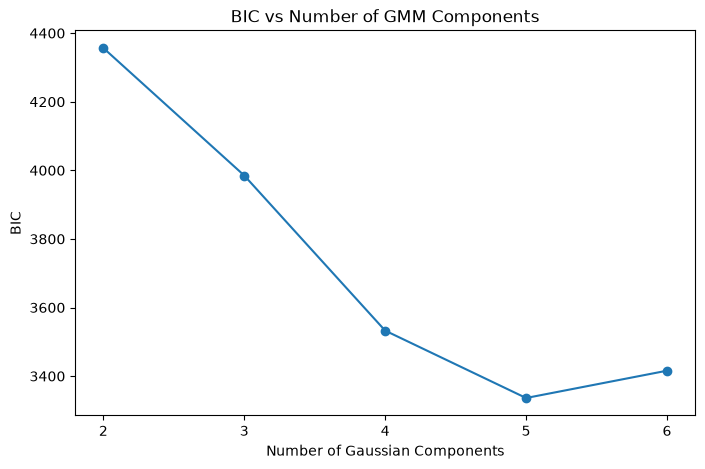

In [73]:
# BIC vs number of GMM components

plt.figure(figsize=(8, 5))

plt.plot(
    list(component_values),
    bic_scores,
    marker="o"
)

plt.xlabel("Number of Gaussian Components")
plt.ylabel("BIC")
plt.title("BIC vs Number of GMM Components")

plt.xticks(list(component_values))
plt.show()

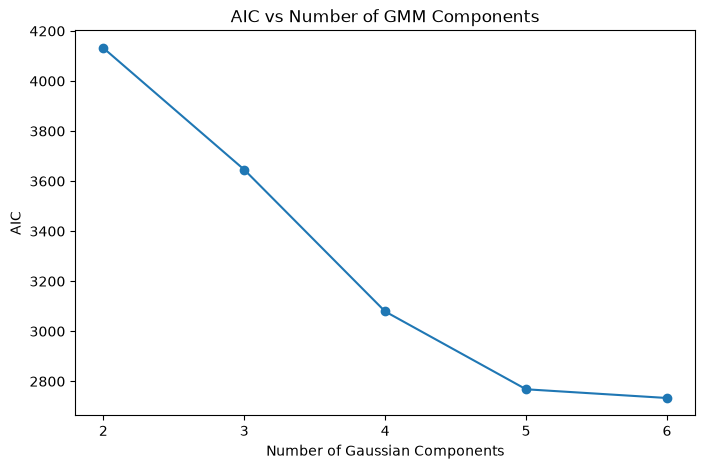

In [74]:
# AIC vs number of GMM components

plt.figure(figsize=(8, 5))

plt.plot(
    list(component_values),
    aic_scores,
    marker="o"
)

plt.xlabel("Number of Gaussian Components")
plt.ylabel("AIC")
plt.title("AIC vs Number of GMM Components")

plt.xticks(list(component_values))
plt.show()

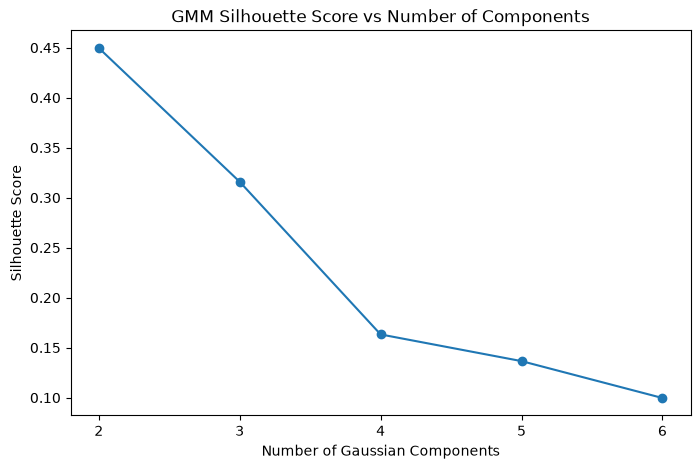

In [75]:
# Silhouette Score vs number of GMM components

plt.figure(figsize=(8, 5))

plt.plot(
    list(component_values),
    gmm_silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Gaussian Components")
plt.ylabel("Silhouette Score")
plt.title("GMM Silhouette Score vs Number of Components")

plt.xticks(list(component_values))
plt.show()

In [76]:
# Fit the final GMM using the number of components selected by BIC

selected_gmm_components = int(best_components_bic)

final_gmm = GaussianMixture(
    n_components=selected_gmm_components,
    random_state=42
)

final_gmm.fit(X_scaled)

gmm_labels = final_gmm.predict(X_scaled)

In [77]:
# Add GMM cluster labels

df_gmm = df.copy()

df_gmm["GMM_Cluster"] = gmm_labels

df_gmm.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,GMM_Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,2
3,1,3,13265,1196,4221,6404,507,1788,3
4,2,3,22615,5410,7198,3915,1777,5185,1


In [78]:
# Number of customers in each GMM cluster

gmm_cluster_counts = (
    df_gmm["GMM_Cluster"]
    .value_counts()
    .sort_index()
)

gmm_cluster_counts

GMM_Cluster
0    185
1     69
2     37
3    147
4      2
Name: count, dtype: int64

In [79]:
# Average spending by GMM cluster

gmm_profiles = (
    df_gmm
    .groupby("GMM_Cluster")[spending_features]
    .mean()
)

gmm_profiles

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
GMM_Cluster,,,,,,
0,7463.675676,6440.454054,9575.724324,1287.891892,3956.383784,1196.372973
1,26355.115942,5438.710145,5155.434783,7632.840580,721.550725,2118.594203
2,10347.756757,18703.945946,27503.432432,2257.162162,11811.243243,4099.297297
3,11077.666667,1570.217687,2176.224490,2760.585034,323.891156,668.061224
4,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000


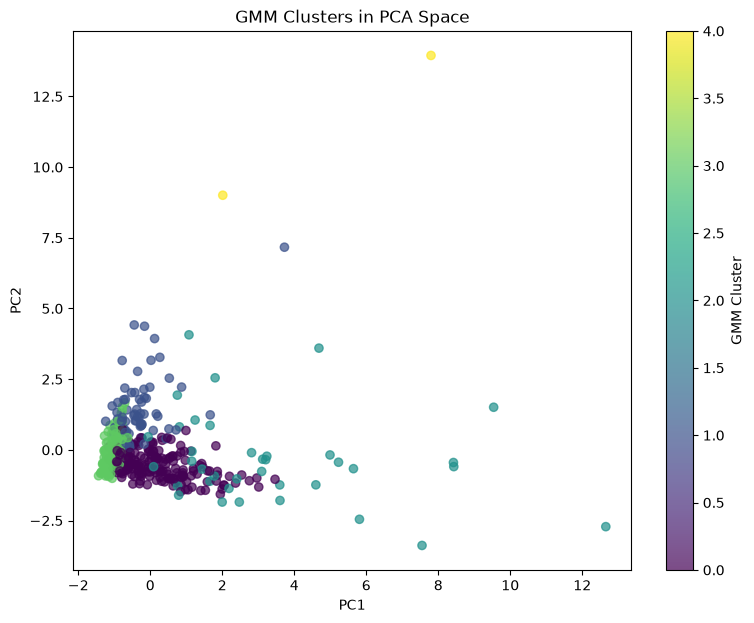

In [80]:
# Visualize GMM clusters in PCA space

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=gmm_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters in PCA Space")

plt.colorbar(
    scatter,
    label="GMM Cluster"
)

plt.show()

In [81]:
# Probability of each customer belonging to each GMM cluster

gmm_probabilities = final_gmm.predict_proba(X_scaled)

gmm_probabilities[:10]

array([[9.99520794e-001, 6.38050300e-005, 4.15400785e-004,
        1.77306972e-028, 0.00000000e+000],
       [9.99121624e-001, 1.51790914e-007, 8.78224645e-004,
        2.90894293e-040, 0.00000000e+000],
       [1.69383663e-011, 3.70015137e-005, 9.99962998e-001,
        1.40231898e-149, 0.00000000e+000],
       [7.08139412e-005, 1.73250318e-001, 1.68939943e-006,
        8.26677178e-001, 0.00000000e+000],
       [1.86966403e-003, 9.59591313e-001, 3.85390225e-002,
        2.74039092e-038, 0.00000000e+000],
       [9.96047125e-001, 3.53306745e-003, 4.19807530e-004,
        1.51500314e-015, 0.00000000e+000],
       [9.99896368e-001, 4.64533267e-008, 1.03585158e-004,
        3.12427284e-029, 0.00000000e+000],
       [9.98782317e-001, 1.09366820e-007, 1.21757402e-003,
        3.57364987e-043, 0.00000000e+000],
       [9.99415696e-001, 4.15202939e-004, 1.68460729e-004,
        6.39966716e-007, 0.00000000e+000],
       [9.97201327e-001, 2.62303551e-036, 2.79867270e-003,
        5.93127392e-196

In [82]:
# Create a readable probability DataFrame

probability_columns = [
    f"GMM_Probability_{i}"
    for i in range(selected_gmm_components)
]

gmm_probability_df = pd.DataFrame(
    gmm_probabilities,
    columns=probability_columns
)

gmm_probability_df.head()

,GMM_Probability_0,GMM_Probability_1,GMM_Probability_2,GMM_Probability_3,GMM_Probability_4
0,9.995208e-01,6.380503e-05,0.000415,1.773070e-28,0.0
1,9.991216e-01,1.517909e-07,0.000878,2.908943e-40,0.0
2,1.693837e-11,3.700151e-05,0.999963,1.402319e-149,0.0
3,7.081394e-05,1.732503e-01,0.000002,8.266772e-01,0.0
4,1.869664e-03,9.595913e-01,0.038539,2.740391e-38,0.0


In [83]:
# Measure cluster assignment ambiguity

sorted_probabilities = np.sort(
    gmm_probabilities,
    axis=1
)

highest_probability = sorted_probabilities[:, -1]
second_highest_probability = sorted_probabilities[:, -2]

probability_gap = (
    highest_probability -
    second_highest_probability
)

gmm_probability_df["Probability_Gap"] = probability_gap

gmm_probability_df["GMM_Cluster"] = gmm_labels

In [84]:
# Customers with the most ambiguous GMM assignments

most_ambiguous = gmm_probability_df.sort_values(
    "Probability_Gap"
)

most_ambiguous.head(10)

,GMM_Probability_0,GMM_Probability_1,GMM_Probability_2,GMM_Probability_3,GMM_Probability_4,Probability_Gap,GMM_Cluster
283,1.153478e-13,4.909997e-01,8.944881e-12,0.509000,0.0,0.018001,3
351,4.898896e-01,8.102424e-102,5.101104e-01,0.000000,0.0,0.020221,2
273,2.166526e-05,4.785275e-01,2.600805e-07,0.521451,0.0,0.042923,3
304,4.594243e-01,1.285226e-93,5.405757e-01,0.000000,0.0,0.081151,2
378,4.410866e-01,1.698917e-02,1.392295e-04,0.541785,0.0,0.100698,3
203,4.393777e-01,4.590158e-03,3.319172e-04,0.555700,0.0,0.116322,3
332,5.647083e-01,4.346767e-01,2.033475e-04,0.000412,0.0,0.130032,0
50,4.041980e-01,5.940178e-01,1.306274e-03,0.000478,0.0,0.189820,1
198,4.819471e-01,2.879955e-01,4.535090e-04,0.229604,0.0,0.193952,0
174,3.351621e-01,1.330314e-01,1.484310e-03,0.530322,0.0,0.195160,3


In [85]:
# Most ambiguous customer

most_ambiguous_index = most_ambiguous.index[0]

print("Customer index:", most_ambiguous_index)

print(
    "\nCluster probabilities:"
)

print(
    gmm_probability_df.loc[
        most_ambiguous_index,
        probability_columns
    ]
)

print(
    "\nOriginal customer spending:"
)

print(
    df.loc[
        most_ambiguous_index,
        spending_features
    ]
)

Customer index: 283

Cluster probabilities:
GMM_Probability_0    1.153478e-13
GMM_Probability_1    4.909997e-01
GMM_Probability_2    8.944881e-12
GMM_Probability_3    5.090003e-01
GMM_Probability_4    0.000000e+00
Name: 283, dtype: float64

Original customer spending:
Fresh               25767
Milk                 3613
Grocery              2013
Frozen              10303
Detergents_Paper      314
Delicassen           1384
Name: 283, dtype: int64


In [86]:
# Compare K-Means and GMM cluster assignments

gmm_kmeans_comparison = pd.crosstab(
    df_kmeans["KMeans_Cluster"],
    df_gmm["GMM_Cluster"]
)

gmm_kmeans_comparison

GMM_Cluster,0,1,2,3,4
KMeans_Cluster,,,,,
0,20,1,24,0,0
1,165,68,13,147,0
2,0,0,0,0,2


### Q23. Which number of Gaussian components gives the lowest BIC?

The lowest BIC is obtained with **5 Gaussian components**, with a BIC value of approximately **3336.13**. The BIC decreases as the number of components increases from 2 to 5, but increases again at 6 components. Therefore, **5 components** provide the best balance between model fit and model complexity according to BIC.

### Q24. How does GMM compare to K-Means in terms of cluster assignments?

K-Means produces **hard cluster assignments**, where each customer is assigned to exactly one cluster. GMM provides **soft probabilistic assignments**, where each customer receives a probability of belonging to every Gaussian component. Therefore, GMM can represent uncertainty in cluster membership, especially for customers located near the boundaries between clusters. This provides more information than the hard assignments produced by K-Means.

### Q25. Which customers have ambiguous cluster probabilities?

Customers with similar probabilities for their two most likely clusters have ambiguous GMM assignments. The most ambiguous customers in this experiment are **Customer 283** and **Customer 351**, with probability gaps of approximately **0.0180** and **0.0202**, respectively. Customer 283 has approximately **49.10% probability of belonging to Cluster 1 and 50.90% probability of belonging to Cluster 3**, making its cluster membership highly uncertain.

### Q26. Pick one ambiguous customer and interpret why the model is uncertain.

Customer **283** is the most ambiguous customer in the GMM results. The model assigns approximately **50.90% probability to Cluster 3** and **49.10% probability to Cluster 1**, making the assignment almost equally likely between the two clusters. The customer has relatively high spending on **Fresh (25,767)** and **Frozen (10,303)**, but lower spending on Grocery and Detergents_Paper. This mixed spending pattern likely places the customer near the boundary between two Gaussian components, resulting in high uncertainty in the cluster assignment.

### Part 5 Conclusion

The Gaussian Mixture Model was evaluated using 2 to 6 Gaussian components. According to **BIC, 5 components** provided the best balance between model fit and complexity, while AIC preferred 6 components and the Silhouette Score preferred 2 components. Unlike K-Means, GMM provides probabilistic cluster assignments, allowing uncertain customers to be identified. Customer 283 was the most ambiguous observation, with approximately equal probabilities of belonging to Clusters 1 and 3. This demonstrates the advantage of GMM's soft clustering approach for customers whose behaviour lies between distinct segments.

### Part 6 – DBSCAN

In [87]:
# DBSCAN clustering

from sklearn.cluster import DBSCAN

In [88]:
# DBSCAN parameter experiment

eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [5, 10]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = dbscan.fit_predict(X_scaled)
        
        # Noise points have label -1
        noise_count = np.sum(labels == -1)
        
        # Number of clusters, excluding noise
        unique_clusters = set(labels)
        n_clusters = len(unique_clusters - {-1})
        
        # Calculate silhouette only when at least
        # two actual clusters exist
        # and there are enough non-noise observations.
        non_noise_mask = labels != -1
        non_noise_labels = labels[non_noise_mask]
        non_noise_data = X_scaled[non_noise_mask]
        
        if (
            n_clusters >= 2
            and len(non_noise_data) > n_clusters
        ):
            silhouette = silhouette_score(
                non_noise_data,
                non_noise_labels
            )
        else:
            silhouette = np.nan
        
        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Number of Clusters": n_clusters,
            "Noise Points": noise_count,
            "Silhouette Score": silhouette
        })

dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results

,eps,min_samples,Number of Clusters,Noise Points,Silhouette Score
0,0.3,5,2,321,0.389505
1,0.3,10,1,363,NaN
2,0.5,5,2,174,0.520979
3,0.5,10,2,227,0.372597
4,0.7,5,1,97,NaN
5,0.7,10,1,129,NaN
6,1.0,5,1,47,NaN
7,1.0,10,1,54,NaN


In [89]:
# Display DBSCAN results sorted by eps and min_samples

dbscan_results.sort_values(
    ["eps", "min_samples"]
).reset_index(drop=True)

,eps,min_samples,Number of Clusters,Noise Points,Silhouette Score
0,0.3,5,2,321,0.389505
1,0.3,10,1,363,NaN
2,0.5,5,2,174,0.520979
3,0.5,10,2,227,0.372597
4,0.7,5,1,97,NaN
5,0.7,10,1,129,NaN
6,1.0,5,1,47,NaN
7,1.0,10,1,54,NaN


In [90]:
# Best DBSCAN configuration according to Silhouette Score

valid_dbscan_results = dbscan_results.dropna(
    subset=["Silhouette Score"]
)

best_dbscan_row = valid_dbscan_results.loc[
    valid_dbscan_results["Silhouette Score"].idxmax()
]

best_dbscan_row

eps                     0.500000
min_samples             5.000000
Number of Clusters      2.000000
Noise Points          174.000000
Silhouette Score        0.520979
Name: 2, dtype: float64

In [91]:
# Select the initial DBSCAN configuration

selected_eps = best_dbscan_row["eps"]
selected_min_samples = int(
    best_dbscan_row["min_samples"]
)

print("Selected eps:", selected_eps)
print("Selected min_samples:", selected_min_samples)

Selected eps: 0.5
Selected min_samples: 5


In [92]:
# Fit the selected DBSCAN model

final_dbscan = DBSCAN(
    eps=selected_eps,
    min_samples=selected_min_samples
)

dbscan_labels = final_dbscan.fit_predict(X_scaled)

In [93]:
# Add DBSCAN cluster labels

df_dbscan = df.copy()

df_dbscan["DBSCAN_Cluster"] = dbscan_labels

df_dbscan.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,DBSCAN_Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,-1
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,-1


In [94]:
# Count DBSCAN clusters and noise points

dbscan_noise_count = np.sum(
    dbscan_labels == -1
)

dbscan_cluster_count = len(
    set(dbscan_labels) - {-1}
)

print("Number of clusters:", dbscan_cluster_count)
print("Number of noise points:", dbscan_noise_count)

Number of clusters: 2
Number of noise points: 174


In [95]:
# Number of customers in each DBSCAN cluster

dbscan_cluster_counts = (
    df_dbscan["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)

dbscan_cluster_counts

DBSCAN_Cluster
-1    174
 0    261
 1      5
Name: count, dtype: int64

In [96]:
# Average spending by DBSCAN cluster
# Noise points (-1) are excluded from cluster profiles

dbscan_profiles = (
    df_dbscan[
        df_dbscan["DBSCAN_Cluster"] != -1
    ]
    .groupby("DBSCAN_Cluster")[spending_features]
    .mean()
)

dbscan_profiles

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
DBSCAN_Cluster,,,,,,
0,9030.398467,3077.318008,4234.061303,1963.43295,1322.1341,881.773946
1,41446.600000,1421.200000,2167.600000,1276.40000,416.2000,784.800000


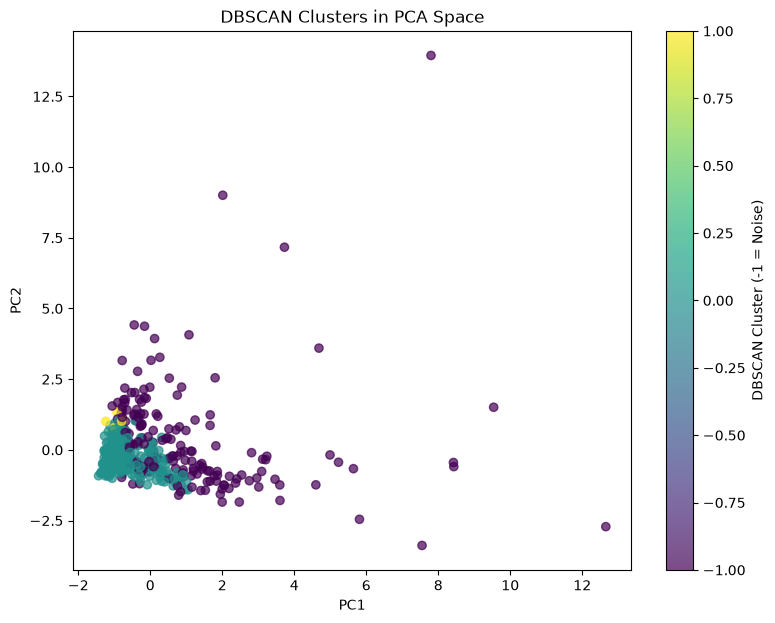

In [97]:
# Visualize DBSCAN clusters in PCA space

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=dbscan_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters in PCA Space")

plt.colorbar(
    scatter,
    label="DBSCAN Cluster (-1 = Noise)"
)

plt.show()

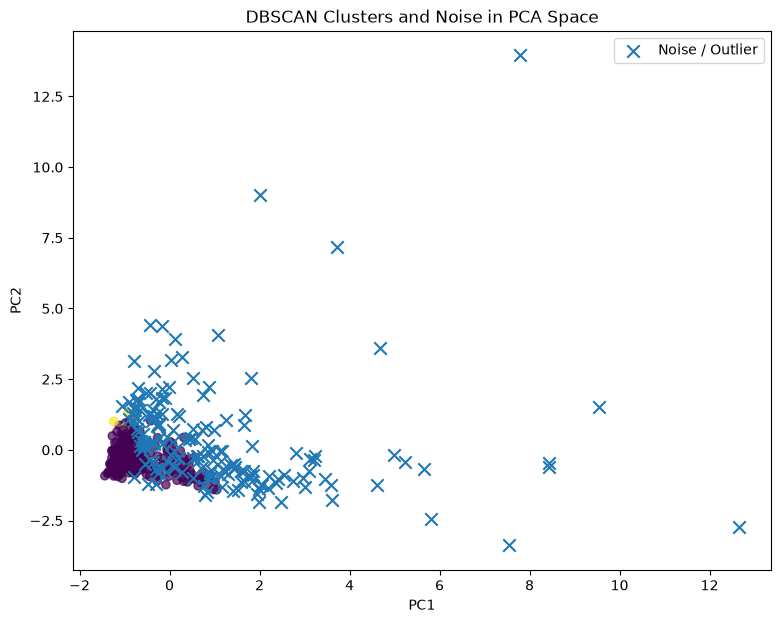

In [98]:
# Highlight DBSCAN noise points in PCA space

noise_mask = dbscan_labels == -1
cluster_mask = dbscan_labels != -1

plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca_df.loc[cluster_mask, "PC1"],
    X_pca_df.loc[cluster_mask, "PC2"],
    c=dbscan_labels[cluster_mask],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    X_pca_df.loc[noise_mask, "PC1"],
    X_pca_df.loc[noise_mask, "PC2"],
    marker="x",
    s=80,
    label="Noise / Outlier"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters and Noise in PCA Space")

plt.legend()

plt.show()

In [99]:
# Inspect DBSCAN noise/outlier customers

noise_customers = df_dbscan[
    df_dbscan["DBSCAN_Cluster"] == -1
]

noise_customers

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,DBSCAN_Cluster
2,2,3,6353,8808,7684,2405,3516,7844,-1
4,2,3,22615,5410,7198,3915,1777,5185,-1
9,2,3,6006,11093,18881,1159,7425,2098,-1
10,2,3,3366,5403,12974,4400,5977,1744,-1
12,2,3,31714,12319,11757,287,3881,2931,-1
...,...,...,...,...,...,...,...,...,...
430,1,3,3097,4230,16483,575,241,2080,-1
431,1,3,8533,5506,5160,13486,1377,1498,-1
435,1,3,29703,12051,16027,13135,182,2204,-1
436,1,3,39228,1431,764,4510,93,2346,-1


In [100]:
# Average spending profile of DBSCAN noise points

noise_profile = (
    noise_customers[spending_features]
    .mean()
)

noise_profile

Fresh               15608.988506
Milk                10000.408046
Grocery             13693.298851
Frozen               4786.275862
Detergents_Paper     5291.373563
Delicassen           2510.781609
dtype: float64

In [101]:
# Compare noise customer spending with overall spending

overall_profile = df[spending_features].mean()

noise_comparison = pd.DataFrame({
    "Overall Average": overall_profile,
    "Noise Customer Average": noise_profile
})

noise_comparison

,Overall Average,Noise Customer Average
Fresh,12000.297727,15608.988506
Milk,5796.265909,10000.408046
Grocery,7951.277273,13693.298851
Frozen,3071.931818,4786.275862
Detergents_Paper,2881.493182,5291.373563
Delicassen,1524.870455,2510.781609


In [102]:
# Compare K-Means and DBSCAN cluster assignments

dbscan_kmeans_comparison = pd.crosstab(
    df_kmeans["KMeans_Cluster"],
    df_dbscan["DBSCAN_Cluster"]
)

dbscan_kmeans_comparison

DBSCAN_Cluster,-1,0,1
KMeans_Cluster,,,
0,45,0,0
1,127,261,5
2,2,0,0


### Q27. How many clusters does DBSCAN identify?

Using the selected parameters **eps = 0.5** and **min_samples = 5**, DBSCAN identifies **2 clusters**. Cluster 0 contains 261 customers and Cluster 1 contains 5 customers. The remaining 174 observations are classified as noise and are not counted as clusters.

### Q28. How many observations are classified as noise?

Using **eps = 0.5** and **min_samples = 5**, DBSCAN classifies **174 out of 440 observations** as noise. This represents approximately **39.5% of the dataset**. These observations do not belong to sufficiently dense regions according to the selected DBSCAN parameters.

### Q29. What happens when eps is increased?

Increasing `eps` increases the neighbourhood radius around each observation. As a result, more observations become connected to dense regions, so the number of noise points decreases. In our experiment with `min_samples = 5`, noise decreased from **321 at eps = 0.3** to **174 at eps = 0.5**, **97 at eps = 0.7**, and **47 at eps = 1.0**. However, at larger values such as 0.7 and 1.0, the clusters merged into a single cluster.

### Q30. What happens when eps is decreased?

Decreasing `eps` makes the neighbourhood around each observation smaller. This makes it harder for observations to satisfy the density requirement, resulting in more points being classified as noise. In our experiment with `min_samples = 5`, reducing `eps` from **0.5 to 0.3** increased the number of noise observations from **174 to 321**.

### Q31. Why does DBSCAN not require us to specify the number of clusters beforehand?

DBSCAN does not require the number of clusters to be specified because it identifies clusters based on the **density of observations**. Instead of providing K, we specify parameters such as `eps` and `min_samples`. DBSCAN then discovers dense regions in the data and determines the number of clusters automatically, while assigning observations that do not belong to dense regions as noise.

### Q32. Are the customers identified as noise necessarily "bad data"?

No. DBSCAN noise points are observations that do not belong to a sufficiently dense region; they are not necessarily incorrect or invalid data. In our experiment, the noise customers actually have higher average spending than the overall dataset across all six spending categories. Therefore, these observations may represent legitimate but unusual customer behaviour rather than bad data.

### Q33. Could a high-spending customer legitimately be considered an outlier?

Yes. A high-spending customer can legitimately be considered an outlier if their spending behaviour is significantly different from the majority of customers. However, being an outlier does not mean that the customer is invalid or that the data is incorrect. Such a customer could represent a legitimate high-value wholesale customer whose purchasing behaviour is rare compared with the rest of the dataset.

### Important Concept: Why might DBSCAN be more useful than K-Means when the dataset contains outliers or irregularly shaped clusters?

DBSCAN can be more useful than K-Means when the dataset contains outliers or irregularly shaped clusters because it groups observations based on **density** rather than distance from cluster centroids. It can explicitly label observations that do not belong to dense regions as **noise**, instead of forcing every observation into a cluster. DBSCAN can also identify clusters with more irregular shapes, whereas K-Means generally works better with compact, centroid-based cluster structures.

### Part 7 — Compare All Algorithms

In [103]:
# Overall algorithm comparison

algorithm_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical - Ward",
        "GMM",
        "DBSCAN"
    ],
    
    "Number of Clusters": [
        selected_k,
        selected_hierarchical_k,
        selected_gmm_components,
        dbscan_cluster_count
    ],
    
    "Silhouette Score": [
        max(silhouette_scores),
        hierarchical_silhouette,
        best_gmm_silhouette,
        best_dbscan_row["Silhouette Score"]
    ],
    
    "Noise Handling": [
        "No",
        "No",
        "No",
        "Yes"
    ],
    
    "Assignment Type": [
        "Hard",
        "Hard",
        "Soft",
        "Hard"
    ]
})

algorithm_comparison

,Algorithm,Number of Clusters,Silhouette Score,Noise Handling,Assignment Type
0,K-Means,3,0.548287,No,Hard
1,Hierarchical - Ward,3,0.264609,No,Hard
2,GMM,5,0.449708,No,Soft
3,DBSCAN,2,0.520979,Yes,Hard


In [104]:
# Silhouette Score of the final BIC-selected GMM

final_gmm_silhouette = silhouette_score(
    X_scaled,
    gmm_labels
)

print(
    "Final GMM Silhouette Score:",
    final_gmm_silhouette
)

Final GMM Silhouette Score: 0.13657124988728198


In [105]:
# Final algorithm comparison

algorithm_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical - Ward",
        "GMM",
        "DBSCAN"
    ],
    
    "Number of Clusters": [
        selected_k,
        selected_hierarchical_k,
        selected_gmm_components,
        dbscan_cluster_count
    ],
    
    "Silhouette Score": [
        max(silhouette_scores),
        hierarchical_silhouette,
        final_gmm_silhouette,
        best_dbscan_row["Silhouette Score"]
    ],
    
    "Noise Handling": [
        "No",
        "No",
        "No",
        "Yes"
    ],
    
    "Assignment Type": [
        "Hard",
        "Hard",
        "Soft",
        "Hard"
    ]
})

algorithm_comparison

,Algorithm,Number of Clusters,Silhouette Score,Noise Handling,Assignment Type
0,K-Means,3,0.548287,No,Hard
1,Hierarchical - Ward,3,0.264609,No,Hard
2,GMM,5,0.136571,No,Soft
3,DBSCAN,2,0.520979,Yes,Hard


In [106]:
kmeans_cluster_counts = (
    df_kmeans["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

kmeans_cluster_counts

KMeans_Cluster
0     45
1    393
2      2
Name: count, dtype: int64

In [107]:
hierarchical_counts

Hierarchical_Cluster
0      6
1    281
2    153
Name: count, dtype: int64

In [108]:
gmm_cluster_counts

GMM_Cluster
0    185
1     69
2     37
3    147
4      2
Name: count, dtype: int64

In [109]:
# Cluster size summary

cluster_size_summary = pd.DataFrame({
    "K-Means": kmeans_cluster_counts,
    "Hierarchical": hierarchical_counts,
    "GMM": gmm_cluster_counts,
    "DBSCAN": dbscan_cluster_counts
})

cluster_size_summary

,K-Means,Hierarchical,GMM,DBSCAN
-1,NaN,NaN,NaN,174.0
0,45.0,6.0,185.0,261.0
1,393.0,281.0,69.0,5.0
2,2.0,153.0,37.0,NaN
3,NaN,NaN,147.0,NaN
4,NaN,NaN,2.0,NaN


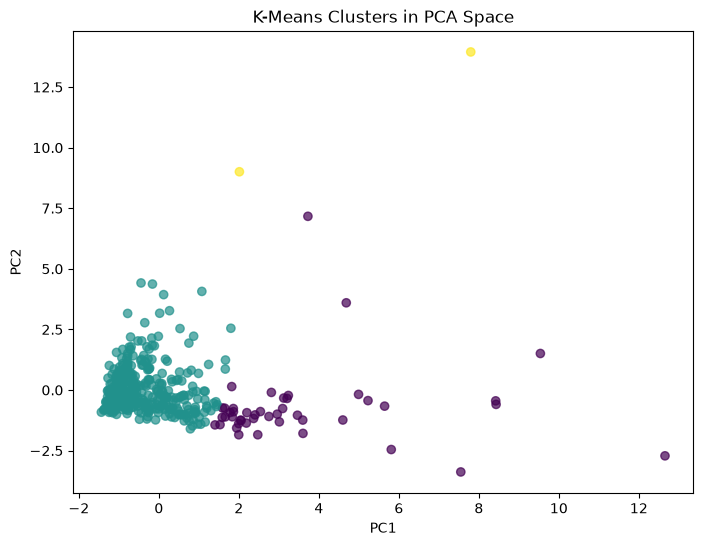

In [110]:
# K-Means PCA visualization

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=final_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in PCA Space")

plt.show()

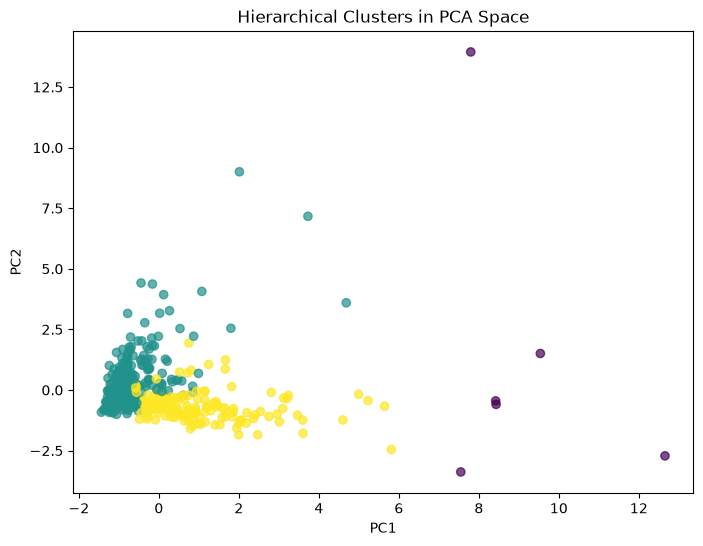

In [111]:
# Hierarchical PCA visualization

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=hierarchical_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clusters in PCA Space")

plt.show()

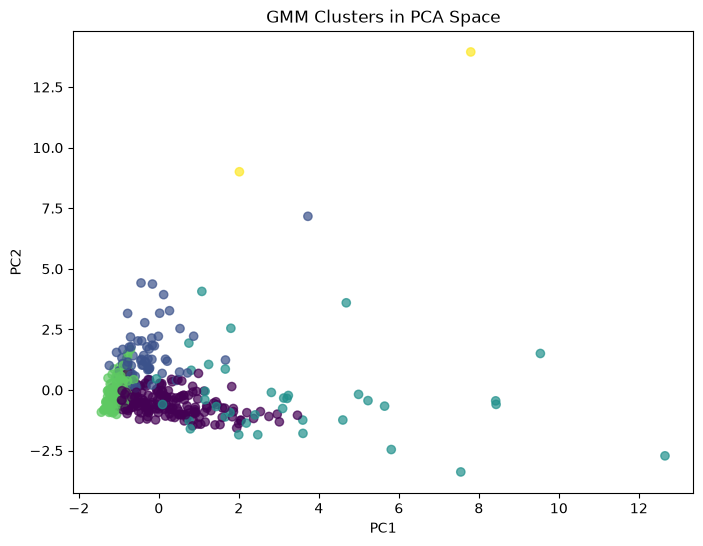

In [112]:
# GMM PCA visualization

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=gmm_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters in PCA Space")

plt.show()

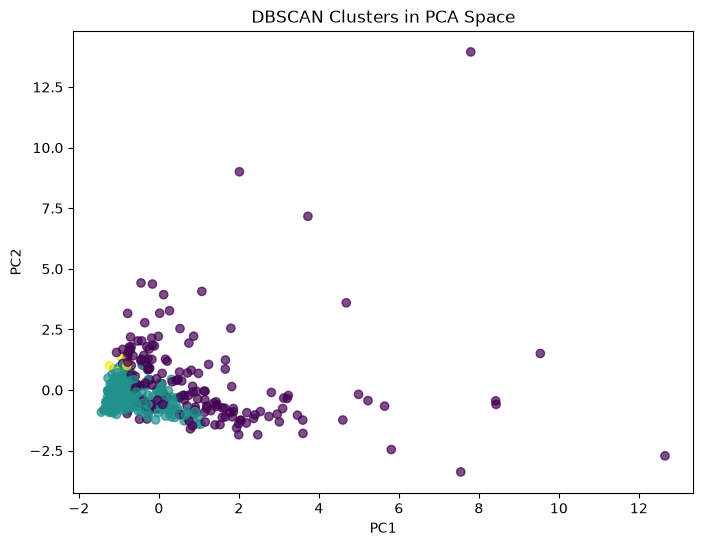

In [113]:
# DBSCAN PCA visualization

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    c=dbscan_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters in PCA Space")

plt.show()


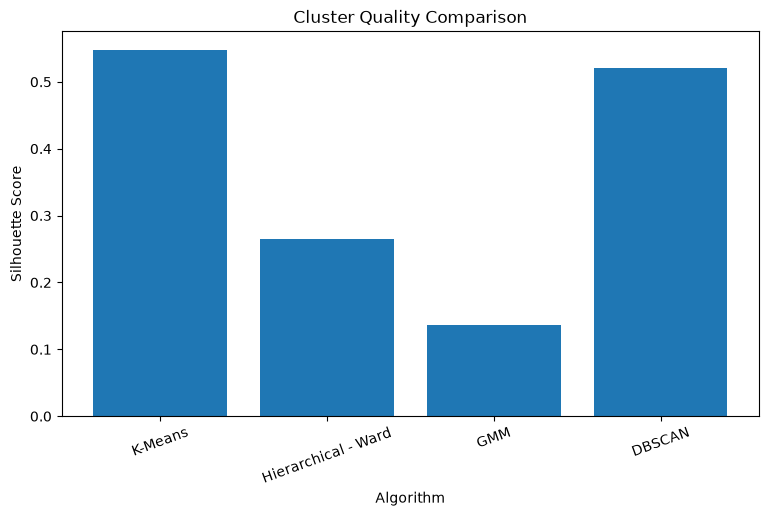

In [114]:
# Compare final Silhouette Scores

plt.figure(figsize=(9, 5))

plt.bar(
    algorithm_comparison["Algorithm"],
    algorithm_comparison["Silhouette Score"]
)

plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")
plt.title("Cluster Quality Comparison")

plt.xticks(rotation=20)

plt.show()


In [115]:
# DBSCAN noise percentage

dbscan_noise_percentage = (
    dbscan_noise_count / len(df)
) * 100

print(
    f"DBSCAN noise percentage: "
    f"{dbscan_noise_percentage:.2f}%"
)

DBSCAN noise percentage: 39.55%


In [116]:
# Hard vs soft assignment comparison

assignment_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "GMM",
        "DBSCAN"
    ],
    
    "Assignment Type": [
        "Hard",
        "Hard",
        "Soft",
        "Hard"
    ]
})

assignment_comparison

,Algorithm,Assignment Type
0,K-Means,Hard
1,Hierarchical,Hard
2,GMM,Soft
3,DBSCAN,Hard


In [117]:
# Parameter sensitivity summary

parameter_sensitivity = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "GMM",
        "DBSCAN"
    ],
    
    "Main Parameter Varied": [
        "K",
        "Linkage",
        "Number of Components",
        "eps / min_samples"
    ],
    
    "Observed Effect": [
        "Cluster quality changed with K",
        "Cluster structure and quality changed strongly with linkage",
        "AIC, BIC and Silhouette favored different component counts",
        "Cluster count and noise changed substantially"
    ]
})

parameter_sensitivity

,Algorithm,Main Parameter Varied,Observed Effect
0,K-Means,K,Cluster quality changed with K
1,Hierarchical,Linkage,Cluster structure and quality changed strongly...
2,GMM,Number of Components,"AIC, BIC and Silhouette favored different comp..."
3,DBSCAN,eps / min_samples,Cluster count and noise changed substantially


In [118]:
# Final Silhouette Score comparison

for _, row in algorithm_comparison.iterrows():
    print(
        f"{row['Algorithm']}: "
        f"{row['Silhouette Score']:.4f}"
    )

K-Means: 0.5483
Hierarchical - Ward: 0.2646
GMM: 0.1366
DBSCAN: 0.5210


### Q34. Did all algorithms produce the same number of clusters?

No. The algorithms produced different numbers of clusters. **K-Means produced 3 clusters, Hierarchical Ward produced 3 clusters, GMM produced 5 clusters, and DBSCAN produced 2 clusters**. The difference occurs because each algorithm uses a different definition of what constitutes a cluster.

### Q35. Why do different algorithms produce different cluster structures?

Different algorithms use different definitions of similarity and cluster formation. **K-Means** forms clusters around centroids using distance, **Hierarchical Clustering** builds clusters using pairwise distances and linkage methods, **GMM** models the data as a mixture of Gaussian probability distributions, and **DBSCAN** identifies dense regions and treats low-density observations as noise. Therefore, the same dataset can produce different cluster structures depending on the clustering method used.

### Q36. Which algorithm produced the most interpretable customer segments?

For this dataset, **K-Means produced the most interpretable customer segments** for practical customer segmentation. It produced 3 clusters with clear differences in spending behaviour. The largest cluster represents the majority of customers, another cluster contains customers with higher spending in categories such as Milk, Grocery, and Detergents_Paper, while a very small cluster represents highly unusual customers. Although the cluster sizes are imbalanced, the centroid-based structure is relatively simple to understand and communicate to a wholesale business.

### Q37. Which algorithm was most sensitive to parameter selection?

**DBSCAN was the most sensitive to parameter selection** in our experiments. Changing `eps` and `min_samples` substantially changed both the number of clusters and the number of noise observations. For example, with `min_samples = 5`, increasing `eps` from **0.3 to 1.0** reduced the number of noise points from **321 to 47** and eventually reduced the number of clusters to one. This shows that DBSCAN's results are highly dependent on its density parameters.

### Q38. Which algorithm handled outliers most effectively?

**DBSCAN handled outliers most effectively** because it explicitly identifies observations that do not belong to sufficiently dense regions as noise. With `eps = 0.5` and `min_samples = 5`, DBSCAN classified **174 observations, or approximately 39.55% of the dataset, as noise**. In contrast, K-Means, Hierarchical Clustering, and GMM assign observations to their respective clusters rather than explicitly identifying them as noise.

### Q39. Which algorithm would you choose for the wholesale company?

I would choose **K-Means** for the wholesale company's customer segmentation. K-Means produced **3 clusters** with the highest Silhouette Score among the final models, approximately **0.5483**. It provides simple and easily interpretable hard cluster assignments, making the resulting customer segments easier to use for business decisions. Although DBSCAN achieved a comparable Silhouette Score of **0.5210**, it classified approximately **39.55% of customers as noise**, making it less suitable for segmenting the majority of customers.

### Q40. Justify your choice using at least three observations from the results.

K-Means is selected based on several observations from the experiment:

1. **Highest Silhouette Score:** K-Means achieved a Silhouette Score of approximately **0.5483**, which was higher than Hierarchical Ward (**0.2646**), GMM (**0.1366**), and DBSCAN (**0.5210**) among the final models.

2. **Simple segmentation:** K-Means produced **3 clusters**, making the customer segments relatively simple to understand and communicate for business decision-making.

3. **No unassigned customers:** Unlike DBSCAN, K-Means does not classify customers as noise. DBSCAN classified **174 customers (39.55%)** as noise, which would leave a large portion of customers outside the main segmentation.

4. **Interpretability:** The K-Means cluster profiles showed meaningful differences in spending behaviour across categories such as Milk, Grocery, and Detergents_Paper, making the segments useful for targeted wholesale strategies.

Therefore, K-Means provides the best overall balance of **cluster quality, simplicity, interpretability, and practical usability** for this wholesale customer segmentation problem.

### Final Algorithm Comparison

| Algorithm | Clusters | Silhouette Score | Noise Handling | Assignment |
|---|---:|---:|---|---|
| **K-Means** | **3** | **0.5483** | No | Hard |
| Hierarchical - Ward | 3 | 0.2646 | No | Hard |
| GMM | 5 | 0.1366 | No | Soft |
| **DBSCAN** | **2** | **0.5210** | **Yes** | Hard |

**Selected algorithm: K-Means**

K-Means was selected because it achieved the highest Silhouette Score among the final models while providing simple and interpretable customer segments without leaving a large proportion of customers unassigned.